Dataset loaded successfully!

Shape of Dataset:
(150, 5)

Column Names:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

First Five Rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null 

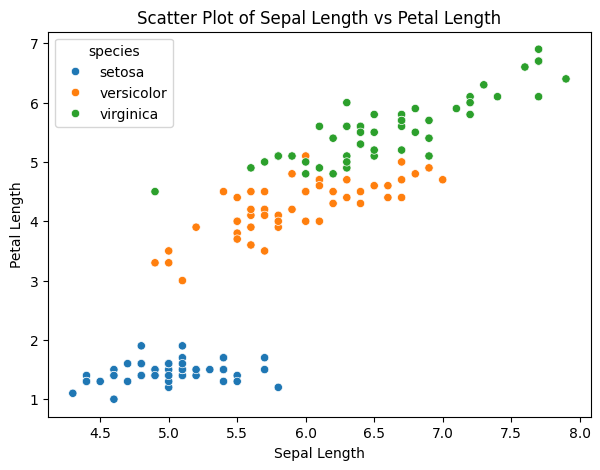

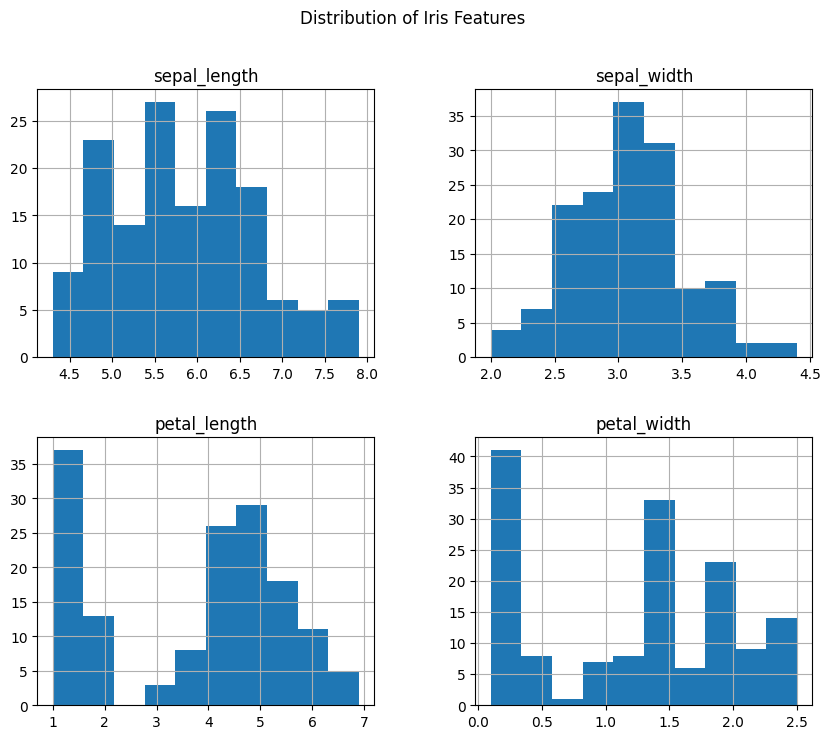

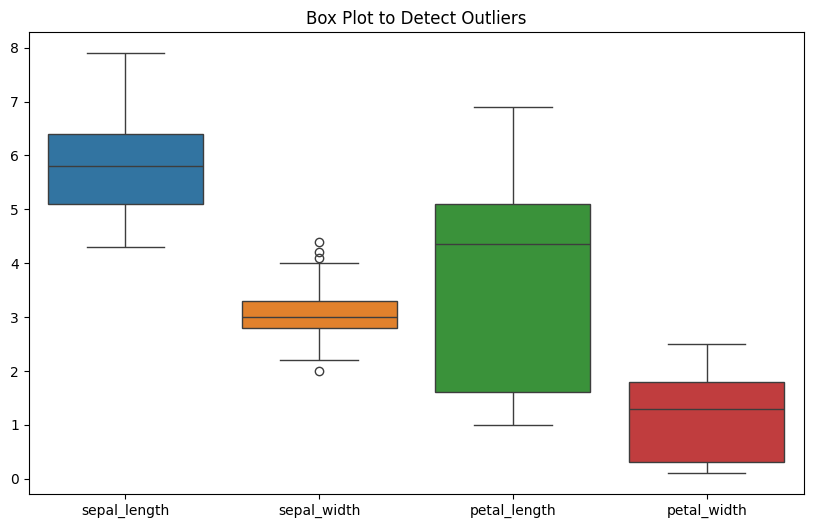

In [5]:
# Exploring and Visualizing a Simple Dataset
# Dataset: Iris Dataset

# Import the required libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Iris dataset

iris = sns.load_dataset("iris")

print("Dataset loaded successfully!\n")

# Print the shape of the dataset

print("Shape of Dataset:")
print(iris.shape)

# Print the column names

print("\nColumn Names:")
print(iris.columns)

# Display the first five rows

print("\nFirst Five Rows:")
print(iris.head())

# Display dataset information

print("\nDataset Information:")
print(iris.info())

# Display summary statistics

print("\nSummary Statistics:")
print(iris.describe())

# Data Visualization

# Scatter Plot

plt.figure(figsize=(7,5))
sns.scatterplot(
    x="sepal_length",
    y="petal_length",
    hue="species",
    data=iris
)

plt.title("Scatter Plot of Sepal Length vs Petal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.show()

# Histogram

iris.hist(figsize=(10,8))
plt.suptitle("Distribution of Iris Features")
plt.show()

# Box Plots

plt.figure(figsize=(10,6))
sns.boxplot(data=iris.drop(columns="species"))

plt.title("Box Plot to Detect Outliers")
plt.show()



Saving archive (1).zip to archive (1) (1).zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
License(s): unknown
heart-disease-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  heart-disease-dataset.zip
  inflating: heart.csv               
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0   

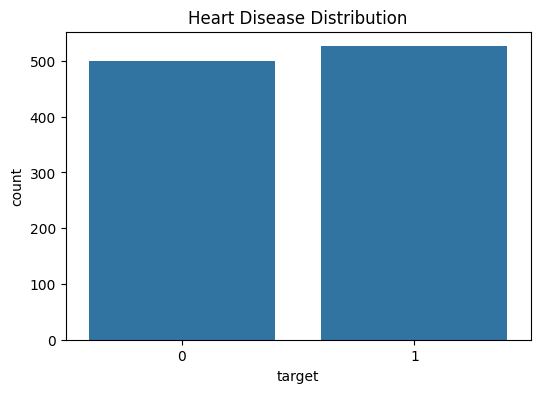

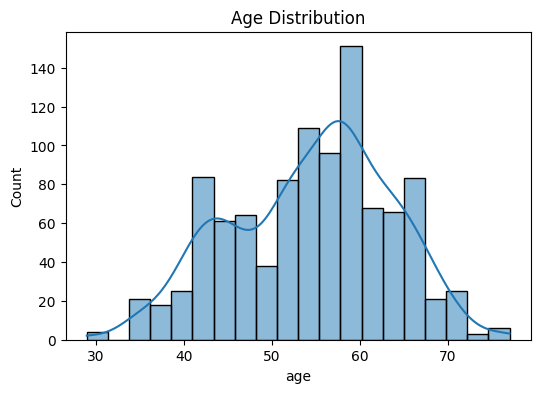

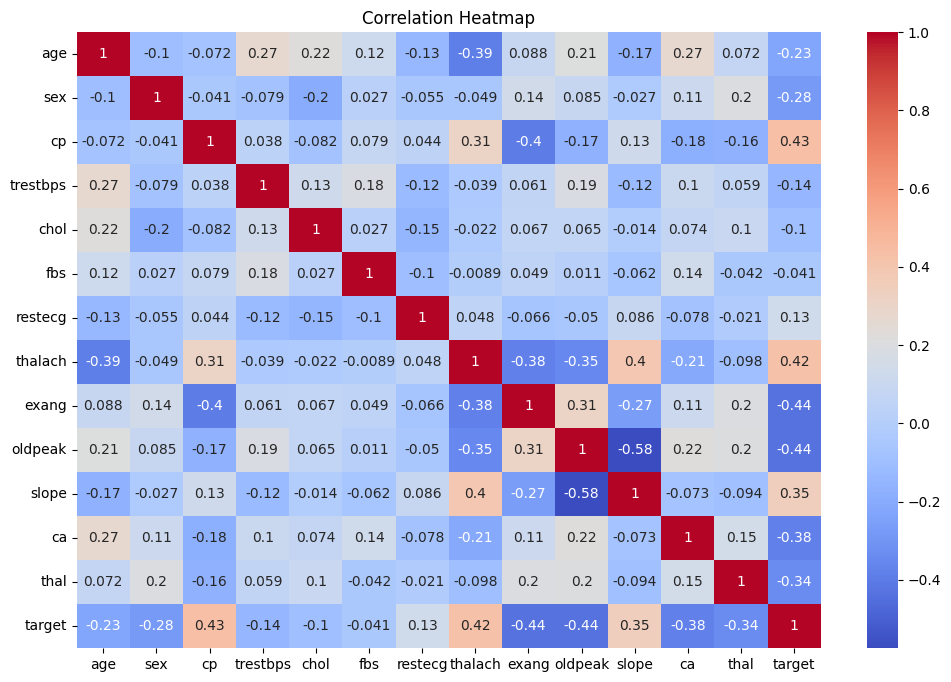


Model Accuracy: 79.51 %


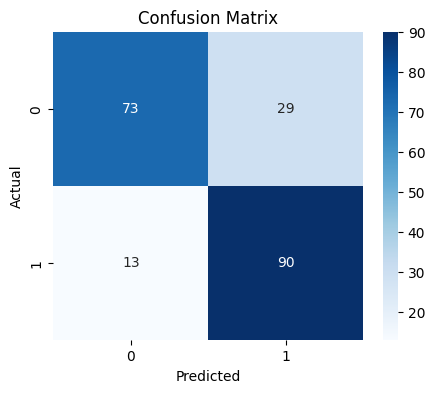

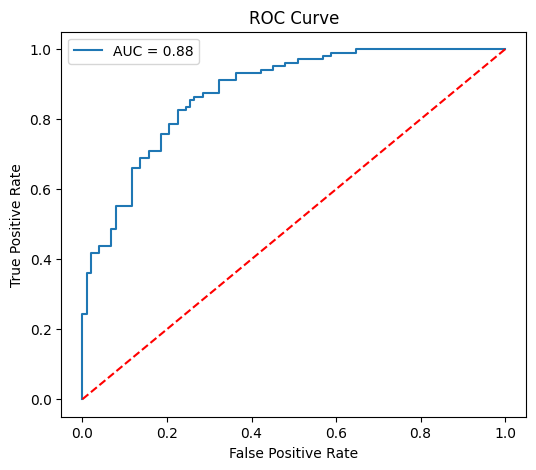


Feature Importance
     Feature  Importance
2         cp    0.847057
10     slope    0.535876
6    restecg    0.262391
7    thalach    0.028880
0        age    0.000642
4       chol   -0.008867
3   trestbps   -0.018159
5        fbs   -0.164529
9    oldpeak   -0.679894
11        ca   -0.814054
8      exang   -0.835868
12      thal   -1.072174
1        sex   -1.714708


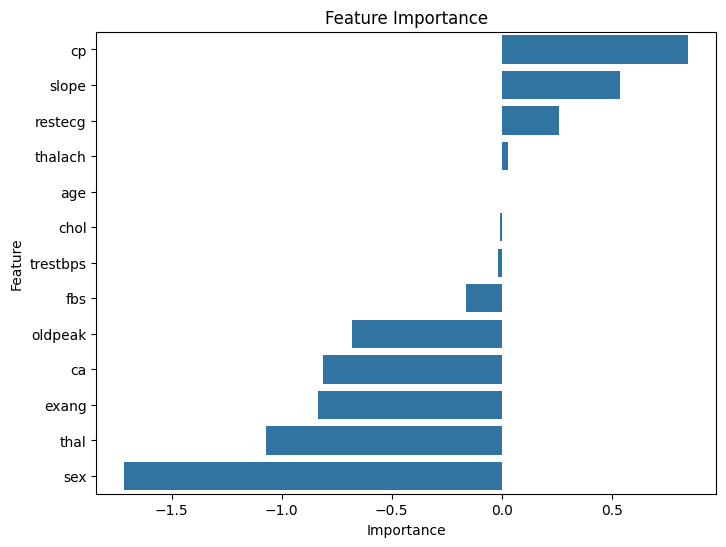


First 10 Predictions
[1 1 0 1 0 1 0 0 1 0]

Actual Values
[1 1 0 1 0 1 0 0 1 0]


In [6]:
# Heart Disease Prediction using Kaggle Dataset
# Install Kaggle
!pip install -q kaggle

# Upload kaggle.json
from google.colab import files
files.upload()

# Create Kaggle folder
import os

os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Download Dataset from Kaggle
!kaggle datasets download -d johnsmith88/heart-disease-dataset

# Extract Dataset
!unzip -o heart-disease-dataset.zip

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

# Load Dataset
df = pd.read_csv("heart.csv")

# Display First Five Rows
print(df.head())

# Dataset Information
print("\nDataset Information")
print(df.info())

# Missing Values
print("\nMissing Values")
print(df.isnull().sum())

# Remove Missing Values
df = df.dropna()

print("\nDataset Shape:", df.shape)

# Exploratory Data Analysis (EDA)

# Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)
plt.title("Heart Disease Distribution")
plt.show()

# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Split Features and Target

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
# Train Logistic Regression Model

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", round(accuracy * 100,2), "%")


# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="AUC = %.2f"%auc)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.coef_[0]
})

importance = importance.sort_values(by="Importance", ascending=False)

print("\nFeature Importance")
print(importance)

plt.figure(figsize=(8,6))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Feature Importance")
plt.show()

# Sample Prediction

print("\nFirst 10 Predictions")
print(y_pred[:10])

print("\nActual Values")
print(y_test.values[:10])


Saving archive (2).zip to archive (2) (1).zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/harlfoxem/housesalesprediction
License(s): CC0-1.0
housesalesprediction.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  housesalesprediction.zip
  inflating: kc_house_data.csv       
First Five Rows
           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_abo

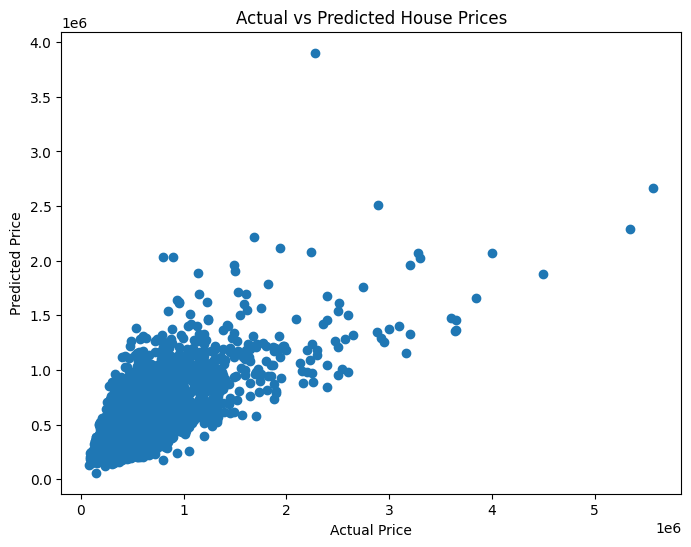


Feature Importance
       Feature   Coefficient
0  sqft_living    305.646131
1     bedrooms -56373.554818
2    bathrooms  11296.920292


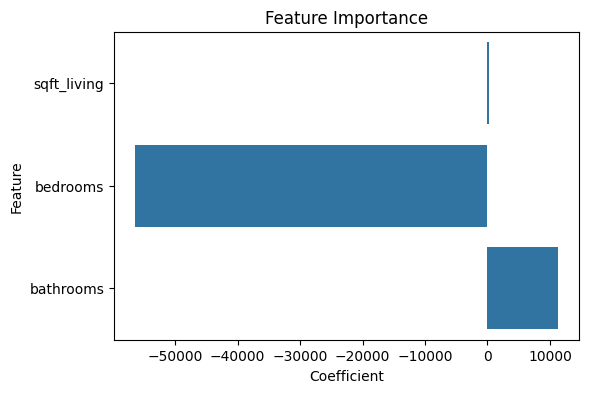

In [7]:
# House Price Prediction
# Install Kaggle
!pip install -q kaggle

# Upload kaggle.json
from google.colab import files
files.upload()

# Configure Kaggle API
import os

os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Download Dataset from Kaggle
!kaggle datasets download -d harlfoxem/housesalesprediction

# Extract Dataset
!unzip -o housesalesprediction.zip

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load Dataset
df = pd.read_csv("kc_house_data.csv")

# Display Dataset
print("First Five Rows")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# Remove Missing Values
df = df.dropna()

print("\nDataset Shape:", df.shape)

# Data Preprocessing

# Select Features
X = df[["sqft_living","bedrooms","bathrooms"]]

# Target Variable
y = df["price"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Linear Regression Model

model = LinearRegression()

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nMean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

# Actual vs Predicted Prices

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

# Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nFeature Importance")
print(importance)

plt.figure(figsize=(6,4))
sns.barplot(data=importance, x="Coefficient", y="Feature")
plt.title("Feature Importance")
plt.show()
